# MDR-TS v10.2
**Temporal-Station Baseline for Soil Moisture Prediction (Reset Notebook)**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR  
**Notebook Type:** One long training + evaluation notebook  
**Last Updated:** Sun Feb 15th, 2026

---

## Model Summary

- **Task:** Regression (soil moisture at 5 cm depth)  
- **Target:** `soil_moisture_5cm`  
- **Temporal resolution:** Daily  
- **Baseline model:** XGBoost (single model first)

---

## Reproducibility

- **Random seed:** 42  
- **Split:** `/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new_updated`  
- **Environment:** local (MacBook M2 Pro)

---

**What's New?**
- New split with 2 extra spatial features

## 0. Imports

In [44]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

from xgboost import XGBRegressor
import optuna
from optuna.integration import XGBoostPruningCallback
from optuna.visualization import plot_optimization_history, plot_param_importances
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("imports loaded")
print(f"seed: {SEED}")

imports loaded
seed: 42


## 1. Data Access

In [45]:
# Project paths
VERSION = "v10"
SUBVERSION = "v10.2"
RUN_NAME = "mdr_ts_v10_2"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v10/v10.2

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 2. Data Loading

In [46]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_new_updated/train_derived_new_updated.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_new_updated/val_derived_new_updated.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_new_updated/test_derived_new_updated.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new_updated/train_derived_new_updated.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new_updated/val_derived_new_updated.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new_updated/test_derived_new_updated.csv


In [47]:
# Dropping TouchNet because it has no rows in the validation split

DROP_STATION = "Touchet_WA_824"

def drop_station(df, station_id=DROP_STATION):
    before = len(df)
    out = df[df["station_id"] != station_id].copy()
    after = len(out)
    print(f"Dropped {station_id}: {before} -> {after} rows (-{before-after})")
    return out

train_df = drop_station(train_df)
val_df   = drop_station(val_df)
test_df  = drop_station(test_df)

Dropped Touchet_WA_824: 16972 -> 13661 rows (-3311)
Dropped Touchet_WA_824: 2919 -> 2919 rows (-0)
Dropped Touchet_WA_824: 2829 -> 2659 rows (-170)


In [48]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 356

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'soil_moisture_5cm', 'D_sin_DOY', 'D_cos_DOY', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1']


## 3. Data Sanity Checks

In [49]:
TARGET_COL = "soil_moisture_5cm"
KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]
EXCLUDE_COLS = set(KEEP_META_COLS + [TARGET_COL]) | {
    "split", "set", "fold", "group", "index", "__index_level_0__"
}

def infer_feature_cols(train_df, val_df, test_df):
    common = set(train_df.columns) & set(val_df.columns) & set(test_df.columns)
    common = [c for c in common if c not in EXCLUDE_COLS and not c.startswith("Unnamed")]

    feature_cols = []
    dropped_non_numeric = []
    for c in common:
        if pd.api.types.is_numeric_dtype(train_df[c]) or pd.api.types.is_bool_dtype(train_df[c]):
            feature_cols.append(c)
        else:
            dropped_non_numeric.append(c)

    feature_cols = sorted(feature_cols)
    dropped_non_numeric = sorted(dropped_non_numeric)

    print("Auto feature selection:")
    print(f"  Common cols across splits: {len(common)}")
    print(f"  Selected numeric/bool features: {len(feature_cols)}")
    if dropped_non_numeric:
        print(f"  Dropped non-numeric cols ({len(dropped_non_numeric)}): {dropped_non_numeric[:20]}")
        if len(dropped_non_numeric) > 20:
            print("  ... (truncated)")

    return feature_cols

FEATURE_COLS = infer_feature_cols(train_df, val_df, test_df)
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])

missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)


Auto feature selection:
  Common cols across splits: 351
  Selected numeric/bool features: 351
Columns locked
  Features: 351
  Target:   soil_moisture_5cm


In [50]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap

[INFO] No temporal leakage detected.


In [51]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00


## 4. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [52]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     13661
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2659
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


## 5. Features

### 5.1 Feature Matrix Construction

In [53]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].astype(float).to_numpy()

X_val   = val_df[FEATURE_COLS].copy()
y_val   = val_df[TARGET_COL].astype(float).to_numpy()

X_test  = test_df[FEATURE_COLS].copy()
y_test  = test_df[TARGET_COL].astype(float).to_numpy()

meta_train = train_df[KEEP_META_COLS].copy()  # dbg
meta_val   = val_df[KEEP_META_COLS].copy()    # dbg
meta_test  = test_df[KEEP_META_COLS].copy()   # dbg

X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
meta_train = meta_train.reset_index(drop=True)
meta_val   = meta_val.reset_index(drop=True)
meta_test  = meta_test.reset_index(drop=True)

print("X/y ready")
print("  X_train:", X_train.shape, "y_train:", y_train.shape)
print("  X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("  X_test: ", X_test.shape,  "y_test: ", y_test.shape)

X_train = X_train.astype("float32")
X_val   = X_val.astype("float32")
X_test  = X_test.astype("float32")

train_medians = X_train.median(axis=0)
X_train = X_train.fillna(train_medians)
X_val   = X_val.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

print("Numeric hygiene done")
print("  NaNs remaining:", int(X_train.isna().sum().sum() + X_val.isna().sum().sum() + X_test.isna().sum().sum()))


X/y ready
  X_train: (13661, 351) y_train: (13661,)
  X_val:   (2919, 351) y_val:   (2919,)
  X_test:  (2659, 351) y_test:  (2659,)
Numeric hygiene done
  NaNs remaining: 0


In [59]:
import numpy as np

def clean_matrix(X, train_medians=None):
    X = X.astype("float32")
    X = X.replace([np.inf, -np.inf], np.nan)

    if train_medians is None:
        train_medians = X.median(axis=0)
    X = X.fillna(train_medians)

    n_bad = np.isinf(X.to_numpy()).sum() + np.isnan(X.to_numpy()).sum()
    if n_bad != 0:
        raise ValueError(f"Still have inf/nan after cleaning: {n_bad}")

    return X, train_medians

X_train, med = clean_matrix(X_train, train_medians=None)
X_val, _      = clean_matrix(X_val, train_medians=med)
X_test, _     = clean_matrix(X_test, train_medians=med)

print("Cleaned matrices:")
print("  X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

Cleaned matrices:
  X_train: (13661, 351) X_val: (2919, 351) X_test: (2659, 351)


### 5.2 Feature Overview

In [60]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

### 5.3 Feature Correlation

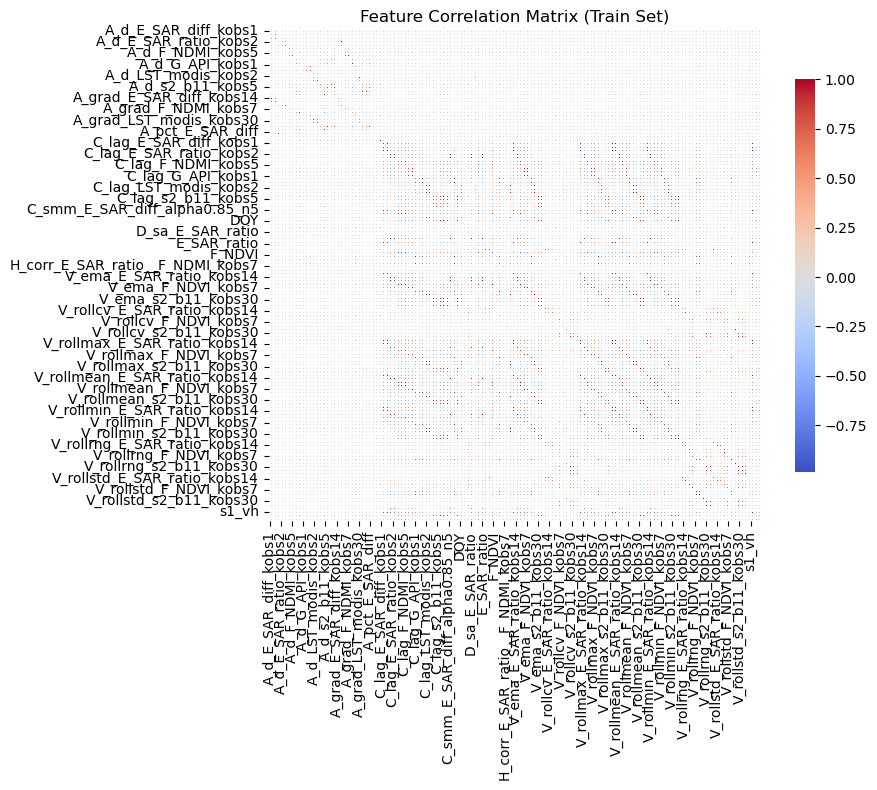

In [61]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

## 6. Model Definition

Using `optuna` here to find the best hyperparameters for a single XGBoost regressor

In [62]:
def eval_regression(y_true, y_pred, name=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    if name:
        print(f"{name} -> R2: {r2:.5f} | MAE: {mae:.5f} | RMSE: {rmse:.5f}")
    return {"r2": r2, "mae": mae, "rmse": rmse}

In [63]:
TIME_BUDGET_SEC = 300

def objective(trial):
    params = {
        "n_estimators": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),

        "gamma": trial.suggest_float("gamma", 1e-6, 2.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),

        "max_leaves": trial.suggest_int("max_leaves", 16, 256, log=True),

        "random_state": SEED,
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "n_jobs": -1,
        "eval_metric": "rmse",
    }

    model = XGBRegressor(**params)

    fit_kwargs = dict(
        X=X_train,
        y=y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
        early_stopping_rounds=50,
    )

    if XGBoostPruningCallback is not None:
        fit_kwargs["callbacks"] = [XGBoostPruningCallback(trial, "validation_0-rmse")]

    try:
        model.fit(**fit_kwargs)
    except TypeError:
        fit_kwargs.pop("early_stopping_rounds", None)
        fit_kwargs.pop("callbacks", None)
        model.fit(**fit_kwargs)

    try:
        best_iter = model.best_iteration
        yhat_val = model.predict(X_val, iteration_range=(0, best_iter + 1))
    except Exception:
        yhat_val = model.predict(X_val)

    return r2_score(y_val, yhat_val)

In [64]:
sampler = TPESampler(seed=SEED, multivariate=True, n_startup_trials=10)
pruner = MedianPruner(n_warmup_steps=100, interval_steps=50)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, timeout=TIME_BUDGET_SEC, show_progress_bar=True)

print("Best R2:", study.best_value)
print("Best params:", study.best_params)

[I 2026-02-15 16:19:50,126] A new study created in memory with name: no-name-8cb31320-1050-4feb-b190-fbbb3ab0808f


   0%|          | 00:00/05:00

[I 2026-02-15 16:20:23,403] Trial 0 finished with value: 0.8160953880726979 and parameters: {'learning_rate': 0.0425378509573798, 'max_depth': 7, 'min_child_weight': 4.480392682684062, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'gamma': 9.614487780312039e-06, 'reg_alpha': 3.0349658373387986e-08, 'reg_lambda': 5.314343038625026, 'max_leaves': 84}. Best is trial 0 with value: 0.8160953880726979.
[I 2026-02-15 16:20:36,930] Trial 1 finished with value: 0.722891176253505 and parameters: {'learning_rate': 0.08329844231669226, 'max_depth': 2, 'min_child_weight': 9.138013915892865, 'subsample': 0.9497327922401265, 'colsample_bytree': 0.7637017332034828, 'gamma': 1.3985711726959038e-05, 'reg_alpha': 3.3300161336615e-07, 'reg_lambda': 0.02034955951308026, 'max_leaves': 68}. Best is trial 0 with value: 0.8160953880726979.
[I 2026-02-15 16:20:53,680] Trial 2 finished with value: 0.7798178485716489 and parameters: {'learning_rate': 0.047753845433560704, 'max_depth': 3

In [65]:
fig1 = plot_optimization_history(study)
fig1.show()

fig2 = plot_param_importances(study)
fig2.show()

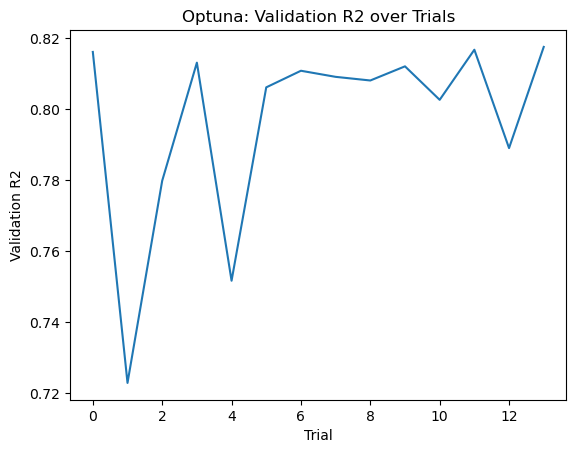

In [66]:
df_trials = study.trials_dataframe()
df_ok = df_trials[df_trials["state"] == "COMPLETE"].copy()

plt.figure()
plt.plot(df_ok["number"], df_ok["value"])
plt.xlabel("Trial")
plt.ylabel("Validation R2")
plt.title("Optuna: Validation R2 over Trials")
plt.show()

In [67]:
best_params = study.best_params.copy()

final_model = XGBRegressor(
    **best_params,
    n_estimators=10000,
    random_state=SEED,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    eval_metric="rmse",
)

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val])

fit_kwargs = dict(
    X=X_trainval,
    y=y_trainval,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

try:
    fit_kwargs["early_stopping_rounds"] = 200
    final_model.fit(**fit_kwargs)
except TypeError:
    fit_kwargs.pop("early_stopping_rounds", None)
    final_model.fit(**fit_kwargs)

yhat_test = final_model.predict(X_test)

print("\nFINAL RESULTS")
eval_regression(y_test, yhat_test, name="Test")

print("\nBest params (final):")
for k, v in best_params.items():
    print(f"  {k}: {v}")


FINAL RESULTS
Test -> R2: 0.74439 | MAE: 0.03830 | RMSE: 0.04857

Best params (final):
  learning_rate: 0.02247018432731144
  max_depth: 7
  min_child_weight: 1.3136983280369596
  subsample: 0.8802386700427667
  colsample_bytree: 0.7091245875032685
  gamma: 1.0957561101819067e-05
  reg_alpha: 0.003603417882096934
  reg_lambda: 18.15752447109269
  max_leaves: 201


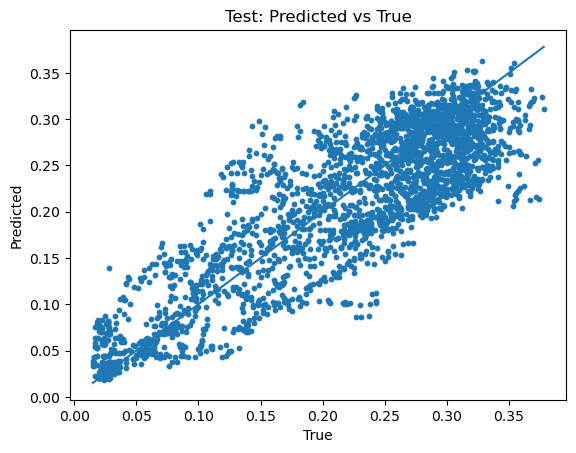

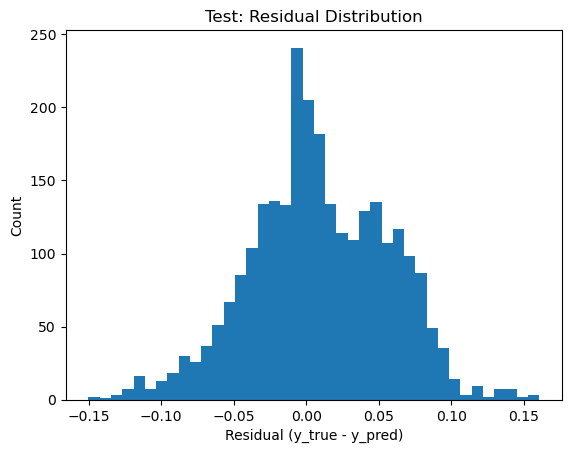

In [68]:
residuals = y_test - yhat_test

# Predicted vs actual
plt.figure()
plt.scatter(y_test, yhat_test, s=10)
mn = min(np.min(y_test), np.min(yhat_test))
mx = max(np.max(y_test), np.max(yhat_test))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Test: Predicted vs True")
plt.show()

# Residual histogram
plt.figure()
plt.hist(residuals, bins=40)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Test: Residual Distribution")
plt.show()

## 7. Post Processing

In [69]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }

### 7.1 Initial | Baseline Evaluation

In [70]:
yhat_train = final_model.predict(X_train)
yhat_val   = final_model.predict(X_val)
yhat_test  = final_model.predict(X_test)

results = {}

results["baseline"] = {
    "val":  metrics(y_val,  yhat_val),
    "test": metrics(y_test, yhat_test),
}

print("Baseline ready")
print("  Val :", results["baseline"]["val"])
print("  Test:", results["baseline"]["test"])

Baseline ready
  Val : {'R2': 0.9997311609005737, 'MAE': 0.0011105908907850374, 'RMSE': 0.0016514057243840437}
  Test: {'R2': 0.7443933483982231, 'MAE': 0.03829913389600951, 'RMSE': 0.04856794464225312}


### 7.2 Linear Calibration

In [71]:
from sklearn.linear_model import LinearRegression

cal = LinearRegression()
cal.fit(yhat_val.reshape(-1, 1), np.asarray(y_val))

yhat_val_cal  = cal.predict(yhat_val.reshape(-1, 1))
yhat_test_cal = cal.predict(yhat_test.reshape(-1, 1))

results["global_calibration"] = {
    "val":  metrics(y_val,  yhat_val_cal),
    "test": metrics(y_test, yhat_test_cal),
}

print("Global calibration ready")
print("  Val :", results["global_calibration"]["val"])
print("  Test:", results["global_calibration"]["test"])

Global calibration ready
  Val : {'R2': 0.9997317607226778, 'MAE': 0.0011133366700679151, 'RMSE': 0.0016495624233287974}
  Test: {'R2': 0.7443955746312862, 'MAE': 0.038298807312471386, 'RMSE': 0.04856773313797708}


### 7.3 Residual Model

In [72]:
from xgboost import XGBRegressor

res_train = np.asarray(y_train) - yhat_train
res_val   = np.asarray(y_val)   - yhat_val

res_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=SEED,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    eval_metric="rmse",
)

fit_kwargs = dict(
    X=X_train,
    y=res_train,
    eval_set=[(X_val, res_val)],
    verbose=False,
)

try:
    fit_kwargs["early_stopping_rounds"] = 100
    res_model.fit(**fit_kwargs)
except TypeError:
    fit_kwargs.pop("early_stopping_rounds", None)
    res_model.fit(**fit_kwargs)

res_hat_val  = res_model.predict(X_val)
res_hat_test = res_model.predict(X_test)

yhat_val_res  = yhat_val  + res_hat_val
yhat_test_res = yhat_test + res_hat_test

results["residual_model"] = {
    "val":  metrics(y_val,  yhat_val_res),
    "test": metrics(y_test, yhat_test_res),
}

print("Residual model ready")
print("  Val :", results["residual_model"]["val"])
print("  Test:", results["residual_model"]["test"])

Residual model ready
  Val : {'R2': 0.9997088395477319, 'MAE': 0.0011787575716564365, 'RMSE': 0.0017185958644484053}
  Test: {'R2': 0.7444035393409516, 'MAE': 0.03831359234824917, 'RMSE': 0.04856697643960133}


### 7.4 Bootstrapping

In [73]:
N_BOOT = 500
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)
n_test = len(y_test)

print(f"Bootstrapping with N={N_BOOT}, test size={n_test}")

Bootstrapping with N=500, test size=2659


In [74]:
boot_results = {
    "r2": [],
    "mae": [],
    "rmse": [],
}

y_test_np = np.asarray(y_test)
yhat_test_np = np.asarray(yhat_test)

for i in range(N_BOOT):
    idx = rng.integers(0, n_test, size=n_test)

    y_true_b = y_test_np[idx]
    y_pred_b = yhat_test_np[idx]

    boot_results["r2"].append(r2_score(y_true_b, y_pred_b))
    boot_results["mae"].append(mean_absolute_error(y_true_b, y_pred_b))
    boot_results["rmse"].append(np.sqrt(mean_squared_error(y_true_b, y_pred_b)))

print("Bootstrapping complete")

Bootstrapping complete


In [75]:
def summarize_bootstrap(x, name):
    x = np.array(x)
    mean = x.mean()
    lo, hi = np.percentile(x, [2.5, 97.5])
    std = x.std()

    print(
        f"{name}: "
        f"mean={mean:.4f}, std={std:.4f}, "
        f"95% CI=[{lo:.4f}, {hi:.4f}]"
    )

summarize_bootstrap(boot_results["r2"], "R2")
summarize_bootstrap(boot_results["mae"], "MAE")
summarize_bootstrap(boot_results["rmse"], "RMSE")

R2: mean=0.7440, std=0.0092, 95% CI=[0.7254, 0.7610]
MAE: mean=0.0383, std=0.0006, 95% CI=[0.0371, 0.0395]
RMSE: mean=0.0486, std=0.0007, 95% CI=[0.0473, 0.0499]


## 7.5 Cross-fit Stacking

In [76]:
def _take(X, idx):
    return X[idx] if hasattr(X, "__getitem__") and not hasattr(X, "iloc") else X.iloc[idx]

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

oof_pred = np.zeros(len(X_train), dtype=float)
test_pred_folds = []

base_params = dict(
    n_estimators=3000,
    learning_rate=0.035996985986582894,
    max_depth=7,
    min_child_weight=8.895297388378221,
    subsample=0.7677976867776913,
    colsample_bytree=0.7383419224932373,
    gamma=1.0018898472602638e-06,
    reg_alpha=1.7566516129215986e-06,
    reg_lambda=17.678396190830714,
    max_leaves=74,
    random_state=SEED,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    eval_metric="rmse",
)

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train), 1):
    X_tr, X_va = _take(X_train, tr_idx), _take(X_train, va_idx)
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    base = XGBRegressor(**base_params)

    fit_kwargs = dict(
        X=X_tr,
        y=y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False,
    )

    try:
        fit_kwargs["early_stopping_rounds"] = 50
        base.fit(**fit_kwargs)
    except TypeError:
        base.fit(X_tr, y_tr)

    try:
        best_iter = base.best_iteration
        oof_pred[va_idx] = base.predict(X_va, iteration_range=(0, best_iter + 1))
        test_pred_folds.append(base.predict(X_test, iteration_range=(0, best_iter + 1)))
    except Exception:
        oof_pred[va_idx] = base.predict(X_va)
        test_pred_folds.append(base.predict(X_test))

yhat_train_oof = oof_pred
yhat_test_base = np.mean(np.vstack(test_pred_folds), axis=0)

res_train_oof = y_train - yhat_train_oof

KeyboardInterrupt: 

---

_Jakob Balkovec_